In [ ]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed/COVID/000000.png' /content/data_processed
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_encrypted/new_dataset_encrypted/COVID/000000.png' /content/data_encrypted

In [ ]:
!git clone https://github.com/JonasGeiping/breaching.git

Cloning into 'breaching'...
remote: Enumerating objects: 5286, done.
remote: Counting objects: 100% (1678/1678), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 5286 (delta 1472), reused 1447 (delta 1447), pack-reused 3608 (from 1)
Receiving objects: 100% (5286/5286), 183.05 MiB | 19.02 MiB/s, done.
Resolving deltas: 100% (4028/4028), done.


In [ ]:
%cd breaching

/content/breaching


In [ ]:
!pip install -e .

Obtaining file:///content/breaching
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.8 MB/s eta 0:00:00
  Building editable for breaching (pyproject.toml) ... done
  Created wheel for breaching: filename=breaching-0.1.2-0.editable-py3-none-any.whl size=12037 sha256=4195175739bcb26f7dae3f0963456e5995e46a0e6d7585045077c044fc298505
  Stored in directory: /tmp/pip-ephem-wheel-cache-q27d9ktq/wheels/4a/36/cc/c3fb5feef1ceb412fd91e9777677a054b9e445304a2c4238a1
Successfully built breaching


In [ ]:
import hydra
hydra.core.global_hydra.GlobalHydra.instance().clear()

In [ ]:
!ls /content/breaching/breaching/config/case

0_sanity_check.yaml	      5_small_batch_imagenet.yaml  impl
10_causal_lang_training.yaml  6_large_batch_cifar.yaml	   __init__.py
1_single_image_small.yaml     8_industry_scale_fl.yaml	   README.md
2_single_imagenet.yaml	      9_bert_training.yaml	   server
4_fedavg_small_scale.yaml     data			   user


In [ ]:
import breaching

cfg_case = breaching.get_case_config(case="2_single_imagenet")

Investigating use case single_imagenet with server type honest_but_curious.


In [ ]:
import torch
import breaching
from PIL import Image
from torchvision import transforms

In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights


def run_gradient_inversion_attack(img_path: str, save_dir: str, file_name: str):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    IMAGE_SIZE = 224
    NUM_CLASSES = 10
    MAX_ITERS = 800
    LR = 0.1
    TV_WEIGHT = 1e-4
    L2_WEIGHT = 1e-6
    PRINT_EVERY = 50
    USE_SIGN_LABEL_RECOVERY = False

    gt_label = torch.tensor([0], dtype=torch.long, device=device)

    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    os.makedirs(save_dir, exist_ok=True)

    def total_variation(x: torch.Tensor) -> torch.Tensor:
        dh = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
        dw = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
        return dh + dw

    def gradient_cosine_loss(dummy_grads, target_grads):
        num = 0.0
        den1 = 0.0
        den2 = 0.0
        for dg, tg in zip(dummy_grads, target_grads):
            num = num + (dg * tg).sum()
            den1 = den1 + (dg * dg).sum()
            den2 = den2 + (tg * tg).sum()
        return 1 - num / (torch.sqrt(den1) * torch.sqrt(den2) + 1e-12)

    def compute_mse(img1: torch.Tensor, img2: torch.Tensor) -> float:
        img1 = torch.clamp(img1, 0, 1)
        img2 = torch.clamp(img2, 0, 1)
        return torch.mean((img1 - img2) ** 2).item()

    def compute_psnr(img1: torch.Tensor, img2: torch.Tensor) -> float:
        mse = compute_mse(img1, img2)
        if mse == 0:
            return float("inf")
        return 10.0 * math.log10(1.0 / mse)

    def tensor_to_numpy_image(x: torch.Tensor):
        x = torch.clamp(x.detach().cpu(), 0, 1)
        x = x.squeeze(0).permute(1, 2, 0).numpy()
        return x

    def show_tensor_image(x: torch.Tensor, title: str):
        plt.imshow(tensor_to_numpy_image(x))
        plt.title(title)
        plt.axis("off")

    def save_tensor_image(x: torch.Tensor, save_path: str, normalize=False):
        x = x.detach().cpu().clone()
        if normalize:
            x = x / (x.max() + 1e-8)
        x = torch.clamp(x, 0, 1)
        x = x.squeeze(0).permute(1, 2, 0).numpy()
        img = Image.fromarray((x * 255).astype("uint8"))
        img.save(save_path)

    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
    ])

    img = Image.open(img_path).convert("RGB")
    gt_data = transform(img).unsqueeze(0).to(device)

    print("device      :", device)
    print("image path  :", img_path)
    print("gt_data     :", tuple(gt_data.shape))
    print("gt_label    :", gt_label.item())

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    model = model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    model.zero_grad(set_to_none=True)
    out = model(gt_data)
    target_loss = criterion(out, gt_label)
    target_grads = torch.autograd.grad(target_loss, model.parameters())
    target_grads = [g.detach().clone() for g in target_grads]

    print("Computed target gradients from YOUR image.")

    if USE_SIGN_LABEL_RECOVERY:
        try:
            grad_last_weight = target_grads[-2]
            recovered_label = torch.argmin(torch.sum(grad_last_weight, dim=1)).view(1).long().to(device)
            used_label = recovered_label
            print("Recovered label:", used_label.item())
        except Exception as e:
            print("Label recovery failed, fallback to gt_label:", str(e))
            used_label = gt_label
    else:
        used_label = gt_label
        print("Using ground-truth label:", used_label.item())

    dummy_data = torch.randn_like(gt_data, device=device, requires_grad=True)

    optimizer = optim.Adam([dummy_data], lr=LR)
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[MAX_ITERS // 2, int(MAX_ITERS * 0.75)],
        gamma=0.3
    )

    history_psnr = []
    history_abs_psnr = []
    history_loss = []

    best_psnr = -1e9
    best_dummy = None
    best_iter = -1

    for it in range(1, MAX_ITERS + 1):
        optimizer.zero_grad(set_to_none=True)

        dummy_clamped = torch.sigmoid(dummy_data)

        pred = model(dummy_clamped)
        dummy_loss_ce = criterion(pred, used_label)

        dummy_grads = torch.autograd.grad(
            dummy_loss_ce,
            model.parameters(),
            create_graph=True
        )

        grad_loss = gradient_cosine_loss(dummy_grads, target_grads)
        tv_loss = total_variation(dummy_clamped)
        l2_loss = torch.mean(dummy_clamped ** 2)

        total_loss = grad_loss + TV_WEIGHT * tv_loss + L2_WEIGHT * l2_loss
        total_loss.backward()

        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            current_dummy = torch.sigmoid(dummy_data)
            current_psnr = compute_psnr(gt_data, current_dummy)

            current_abs_diff = torch.abs(
                torch.clamp(gt_data, 0, 1) - torch.clamp(current_dummy, 0, 1)
            )
            zero_img = torch.zeros_like(current_abs_diff)
            current_abs_psnr = compute_psnr(current_abs_diff, zero_img)

            history_loss.append(total_loss.item())
            history_psnr.append(current_psnr)
            history_abs_psnr.append(current_abs_psnr)

            if current_psnr > best_psnr:
                best_psnr = current_psnr
                best_dummy = current_dummy.detach().clone()
                best_iter = it

        if it % PRINT_EVERY == 0 or it == 1:
            mse_now = compute_mse(gt_data, torch.sigmoid(dummy_data))
            print(
                f"iter={it:04d} | "
                f"total_loss={total_loss.item():.6f} | "
                f"grad_loss={grad_loss.item():.6f} | "
                f"tv={tv_loss.item():.6f} | "
                f"PSNR={current_psnr:.2f} dB | "
                f"Abs-PSNR={current_abs_psnr:.2f} dB | "
                f"MSE={mse_now:.6f}"
            )

    final_dummy = best_dummy
    final_psnr = compute_psnr(gt_data, final_dummy)
    final_mse = compute_mse(gt_data, final_dummy)

    absolute_diff = torch.abs(
        torch.clamp(gt_data, 0, 1) - torch.clamp(final_dummy, 0, 1)
    )
    zero_img = torch.zeros_like(absolute_diff)
    absolute_psnr = compute_psnr(absolute_diff, zero_img)

    print("\n================ FINAL RESULT ================")
    print(f"Best iter     : {best_iter}")
    print(f"Final MSE     : {final_mse:.6f}")
    print(f"Final PSNR    : {final_psnr:.2f} dB")
    print(f"Absolute PSNR : {absolute_psnr:.2f} dB")

    # =========================
    # SAVE IMAGES
    # =========================
    original_path = os.path.join(save_dir, f"{file_name}_original_input.png")
    recovered_path = os.path.join(save_dir, f"{file_name}_recovered.png")
    absolute_diff_path = os.path.join(save_dir, f"{file_name}_absolute_diff.png")
    comparison_path = os.path.join(save_dir, f"{file_name}_comparison.png")

    save_tensor_image(gt_data, original_path, normalize=False)
    save_tensor_image(final_dummy, recovered_path, normalize=False)
    save_tensor_image(absolute_diff, absolute_diff_path, normalize=True)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    show_tensor_image(gt_data, "Original Input")

    plt.subplot(1, 3, 2)
    show_tensor_image(final_dummy, f"Recovered\nPSNR={final_psnr:.2f} dB")

    plt.subplot(1, 3, 3)
    show_tensor_image(
        absolute_diff / (absolute_diff.max() + 1e-8),
        f"Absolute Difference\nAbs-PSNR={absolute_psnr:.2f} dB"
    )

    plt.tight_layout()
    plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("\nSaved files:")
    print(" -", original_path)
    print(" -", recovered_path)
    print(" -", absolute_diff_path)
    print(" -", comparison_path)

    return {
        "best_iter": best_iter,
        "final_psnr": final_psnr,
        "final_mse": final_mse,
        "absolute_psnr": absolute_psnr,
        "original_path": original_path,
        "recovered_path": recovered_path,
        "absolute_diff_path": absolute_diff_path,
        "comparison_path": comparison_path,
    }



device      : cuda
image path  : /content/tanaka.png
gt_data     : (1, 3, 224, 224)
gt_label    : 0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Computed target gradients from YOUR image.
Using ground-truth label: 0
iter=0001 | total_loss=0.728929 | grad_loss=0.728881 | tv=0.479148 | PSNR=11.13 dB | Abs-PSNR=11.13 dB | MSE=0.077020
iter=0050 | total_loss=0.219227 | grad_loss=0.219175 | tv=0.514992 | PSNR=10.52 dB | Abs-PSNR=10.52 dB | MSE=0.088729
iter=0100 | total_loss=0.128975 | grad_loss=0.128923 | tv=0.519818 | PSNR=10.49 dB | Abs-PSNR=10.49 dB | MSE=0.089387
iter=0150 | total_loss=0.108483 | grad_loss=0.108430 | tv=0.520222 | PSNR=10.53 dB | Abs-PSNR=10.53 dB | MSE=0.088505
iter=0200 | total_loss=0.133811 | grad_loss=0.133759 | tv=0.523401 | PSNR=10.52 dB | Abs-PSNR=10.52 dB | MSE=0.088641
iter=0250 | total_loss=0.097445 | grad_loss=0.097393 | tv=0.524360 | PSNR=10.55 dB | Abs-PSNR=10.55 dB | MSE=0.088178
iter=0300 | total_loss=0.114564 | grad_loss=0.114510 | tv=0.533366 | PSNR=10.41 dB | Abs-PSNR=10.41 dB | MSE=0.090975
iter=0350 | total_loss=0.085924 | grad_loss=0.085869 | tv=0.540490 | PSNR=10.36 dB | Abs-PSNR=10.36 dB 

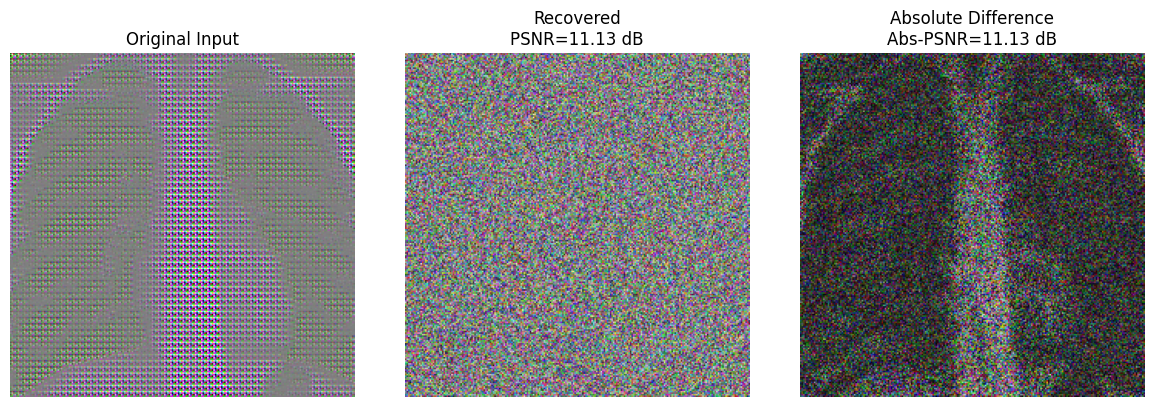


Saved files:
 - /content/my_outputs/Tanaka_decryp_original_input.png
 - /content/my_outputs/Tanaka_decryp_recovered.png
 - /content/my_outputs/Tanaka_decryp_absolute_diff.png
 - /content/my_outputs/Tanaka_decryp_comparison.png
/content/my_outputs/Tanaka_decryp_comparison.png


In [ ]:
# =========================
# RUN
# =========================
result = run_gradient_inversion_attack(
    "/content/tanaka.png",
    "/content/my_outputs",
    "Tanaka_decryp"
)
print(result["comparison_path"])

device      : cuda
image path  : /content/skk.png
gt_data     : (1, 3, 224, 224)
gt_label    : 0
Computed target gradients from YOUR image.
Using ground-truth label: 0
iter=0001 | total_loss=0.381285 | grad_loss=0.381237 | tv=0.479148 | PSNR=11.11 dB | Abs-PSNR=11.11 dB | MSE=0.077362
iter=0050 | total_loss=0.142362 | grad_loss=0.142311 | tv=0.513964 | PSNR=10.58 dB | Abs-PSNR=10.58 dB | MSE=0.087477
iter=0100 | total_loss=0.108247 | grad_loss=0.108195 | tv=0.521218 | PSNR=10.48 dB | Abs-PSNR=10.48 dB | MSE=0.089580
iter=0150 | total_loss=0.110433 | grad_loss=0.110380 | tv=0.526524 | PSNR=10.41 dB | Abs-PSNR=10.41 dB | MSE=0.091005
iter=0200 | total_loss=0.107417 | grad_loss=0.107364 | tv=0.529999 | PSNR=10.37 dB | Abs-PSNR=10.37 dB | MSE=0.091869
iter=0250 | total_loss=0.101836 | grad_loss=0.101782 | tv=0.535424 | PSNR=10.30 dB | Abs-PSNR=10.30 dB | MSE=0.093291
iter=0300 | total_loss=0.115878 | grad_loss=0.115824 | tv=0.544318 | PSNR=10.19 dB | Abs-PSNR=10.19 dB | MSE=0.095824
iter=0

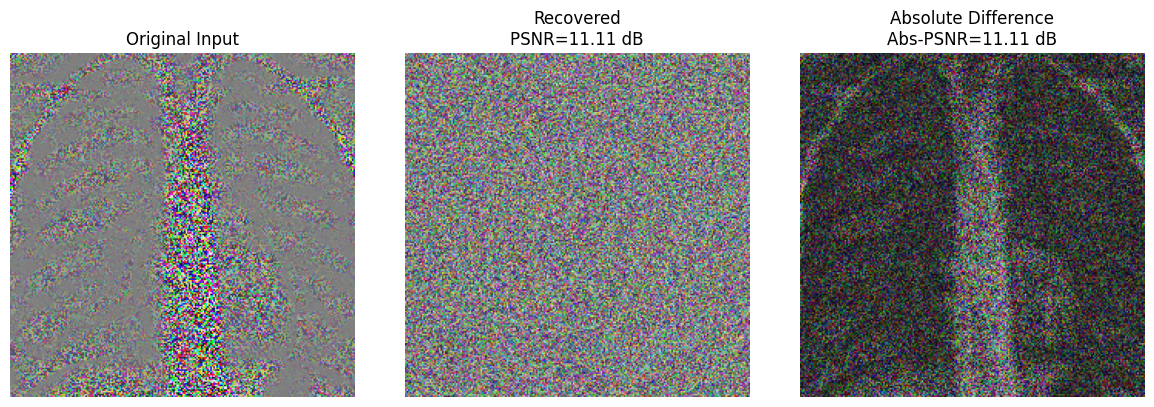


Saved files:
 - /content/my_outputs/SKK_decryp_original_input.png
 - /content/my_outputs/SKK_decryp_recovered.png
 - /content/my_outputs/SKK_decryp_absolute_diff.png
 - /content/my_outputs/SKK_decryp_comparison.png
/content/my_outputs/SKK_decryp_comparison.png


In [ ]:
result = run_gradient_inversion_attack(
    "/content/skk.png",
    "/content/my_outputs",
    "SKK_decryp"
)
print(result["comparison_path"])

device      : cuda
image path  : /content/huang2022.png
gt_data     : (1, 3, 224, 224)
gt_label    : 0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 243MB/s]


Computed target gradients from YOUR image.
Using ground-truth label: 0
iter=0001 | total_loss=0.545832 | grad_loss=0.545784 | tv=0.479148 | PSNR=11.47 dB | Abs-PSNR=11.47 dB | MSE=0.071313
iter=0050 | total_loss=0.229587 | grad_loss=0.229537 | tv=0.499727 | PSNR=10.79 dB | Abs-PSNR=10.79 dB | MSE=0.083317
iter=0100 | total_loss=0.147076 | grad_loss=0.147025 | tv=0.500869 | PSNR=10.57 dB | Abs-PSNR=10.57 dB | MSE=0.087782
iter=0150 | total_loss=0.157666 | grad_loss=0.157616 | tv=0.501395 | PSNR=10.40 dB | Abs-PSNR=10.40 dB | MSE=0.091297
iter=0200 | total_loss=0.142919 | grad_loss=0.142869 | tv=0.501004 | PSNR=10.29 dB | Abs-PSNR=10.29 dB | MSE=0.093627
iter=0250 | total_loss=0.144761 | grad_loss=0.144711 | tv=0.502594 | PSNR=10.16 dB | Abs-PSNR=10.16 dB | MSE=0.096309
iter=0300 | total_loss=0.131365 | grad_loss=0.131314 | tv=0.506272 | PSNR=10.03 dB | Abs-PSNR=10.03 dB | MSE=0.099354
iter=0350 | total_loss=0.102057 | grad_loss=0.102006 | tv=0.507298 | PSNR=9.94 dB | Abs-PSNR=9.94 dB | 

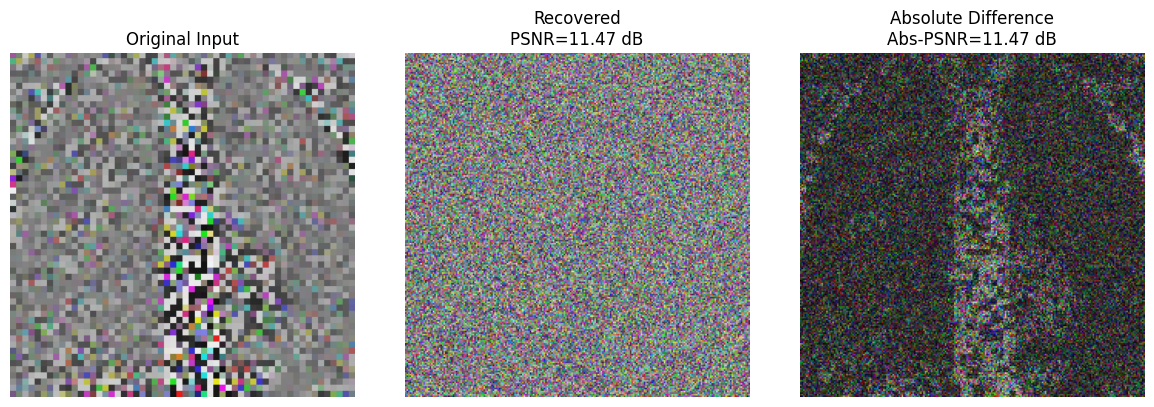


Saved files:
 - /content/my_outputs/huang2022_decryp_original_input.png
 - /content/my_outputs/huang2022_decryp_recovered.png
 - /content/my_outputs/huang2022_decryp_absolute_diff.png
 - /content/my_outputs/huang2022_decryp_comparison.png
/content/my_outputs/huang2022_decryp_comparison.png


In [ ]:
result = run_gradient_inversion_attack(
    "/content/huang2022.png",
    "/content/my_outputs",
    "huang2022_decryp"
)
print(result["comparison_path"])

device      : cuda
image path  : /content/my_method.png
gt_data     : (1, 3, 224, 224)
gt_label    : 0
Computed target gradients from YOUR image.
Using ground-truth label: 0
iter=0001 | total_loss=0.812308 | grad_loss=0.812259 | tv=0.479148 | PSNR=6.58 dB | Abs-PSNR=6.58 dB | MSE=0.219657
iter=0050 | total_loss=0.134722 | grad_loss=0.134670 | tv=0.516938 | PSNR=6.35 dB | Abs-PSNR=6.35 dB | MSE=0.231958
iter=0100 | total_loss=0.227445 | grad_loss=0.227392 | tv=0.525485 | PSNR=6.32 dB | Abs-PSNR=6.32 dB | MSE=0.233095
iter=0150 | total_loss=0.107917 | grad_loss=0.107863 | tv=0.536465 | PSNR=6.29 dB | Abs-PSNR=6.29 dB | MSE=0.234757
iter=0200 | total_loss=0.107145 | grad_loss=0.107090 | tv=0.546794 | PSNR=6.27 dB | Abs-PSNR=6.27 dB | MSE=0.236238
iter=0250 | total_loss=0.086722 | grad_loss=0.086666 | tv=0.555989 | PSNR=6.25 dB | Abs-PSNR=6.25 dB | MSE=0.237190
iter=0300 | total_loss=0.076130 | grad_loss=0.076073 | tv=0.561986 | PSNR=6.25 dB | Abs-PSNR=6.25 dB | MSE=0.237191
iter=0350 | to

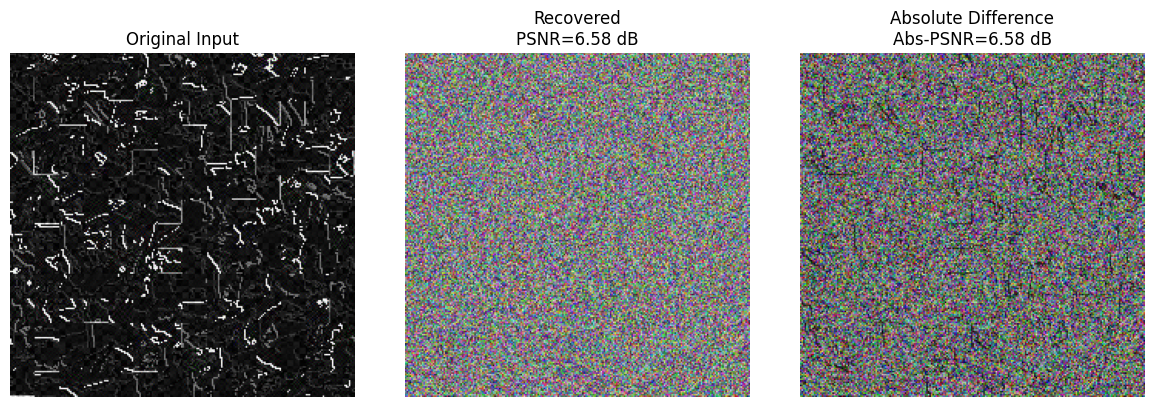


Saved files:
 - /content/my_outputs/my_decryp_original_input.png
 - /content/my_outputs/my_decryp_recovered.png
 - /content/my_outputs/my_decryp_absolute_diff.png
 - /content/my_outputs/my_decryp_comparison.png
/content/my_outputs/my_decryp_comparison.png


In [ ]:
result = run_gradient_inversion_attack(
    "/content/my_method.png",
    "/content/my_outputs",
    "my_decryp"
)
print(result["comparison_path"])

In [ ]:
# ============================================================
# LPIPS from 2 image paths
# input_path  = raw/original image
# output_path = reconstructed / attacked image
# ============================================================

import os
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

try:
    import lpips
except ImportError:
    !pip -q install lpips
    import lpips


def _load_img_rgb(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    img = Image.open(path).convert("RGB")
    return img


def _img_to_tensor_lpips(img_pil, device):
    """
    LPIPS expects tensor in [-1, 1], shape [1, 3, H, W]
    """
    arr = np.array(img_pil).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)  # [1,3,H,W]
    tensor = tensor * 2.0 - 1.0
    return tensor.to(device)


def compute_lpips_from_paths(input_path, output_path, net='alex', device=None, resize_to_input=True):
    """
    Args:
        input_path:  path to raw/original image
        output_path: path to reconstructed/attacked image
        net:         'alex', 'vgg', or 'squeeze'
        device:      'cuda' / 'cpu' / None
        resize_to_input: if True, resize output image to match input image size

    Returns:
        lpips_score (float)
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    img_ref = _load_img_rgb(input_path)
    img_out = _load_img_rgb(output_path)

    if resize_to_input and img_ref.size != img_out.size:
        img_out = img_out.resize(img_ref.size, Image.BILINEAR)

    x = _img_to_tensor_lpips(img_ref, device)
    y = _img_to_tensor_lpips(img_out, device)

    model = lpips.LPIPS(net=net).to(device)
    model.eval()

    with torch.no_grad():
        score = model(x, y).item()

    print("=" * 80)
    print("LPIPS evaluation finished")
    print(f"Reference image : {input_path}")
    print(f"Compared image  : {output_path}")
    print(f"Network         : {net}")
    print(f"Device          : {device}")
    print(f"LPIPS score     : {score:.6f}")
    print("=" * 80)

    return score


# =========================
# Example
# =========================
# lp = compute_lpips_from_paths(
#     input_path="/content/raw.png",
#     output_path="/content/reconstructed.png",
#     net="alex"
# )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
import math
import numpy as np
import cv2


def compute_psnr_between_two_images(img1: np.ndarray, img2: np.ndarray) -> float:
    """
    Tính PSNR giữa 2 ảnh numpy uint8 hoặc float.
    img1, img2: shape (H, W, C)
    """
    if img1.shape != img2.shape:
        raise ValueError(f"Shape không khớp: {img1.shape} vs {img2.shape}")

    img1 = np.clip(img1.astype(np.float32) / 255.0, 0.0, 1.0)
    img2 = np.clip(img2.astype(np.float32) / 255.0, 0.0, 1.0)

    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float("inf")

    return 10.0 * math.log10(1.0 / mse)


def avg_pool_3x3_same(img: np.ndarray) -> np.ndarray:
    """
    Average pooling 3x3, stride 1, same padding
    img: (H, W, C)
    """
    h, w, c = img.shape
    padded = np.pad(img, ((1, 1), (1, 1), (0, 0)), mode="reflect")
    out = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            patch = padded[i:i+3, j:j+3, :]
            out[i, j, :] = np.mean(patch, axis=(0, 1))

    return out


def compute_ssim_between_two_images(img1: np.ndarray, img2: np.ndarray) -> float:
    """
    Tính SSIM giữa 2 ảnh numpy.
    img1, img2: shape (H, W, C), uint8 hoặc float
    """
    if img1.shape != img2.shape:
        raise ValueError(f"Shape không khớp: {img1.shape} vs {img2.shape}")

    img1 = np.clip(img1.astype(np.float32) / 255.0, 0.0, 1.0)
    img2 = np.clip(img2.astype(np.float32) / 255.0, 0.0, 1.0)

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu1 = avg_pool_3x3_same(img1)
    mu2 = avg_pool_3x3_same(img2)

    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = avg_pool_3x3_same(img1 * img1) - mu1_sq
    sigma2_sq = avg_pool_3x3_same(img2 * img2) - mu2_sq
    sigma12 = avg_pool_3x3_same(img1 * img2) - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / (
        (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    )

    return float(np.mean(ssim_map))


def load_image_as_array(path: str, image_size: int = None) -> np.ndarray:
    """
    Đọc ảnh bằng cv2, trả về RGB numpy array uint8
    """
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if image_size is not None:
        img = cv2.resize(img, (image_size, image_size))

    return img


def compute_metrics_from_paths(path1: str, path2: str, image_size: int = None):
    """
    Trả về cả PSNR và SSIM từ 2 path ảnh
    """
    img1 = load_image_as_array(path1, image_size=image_size)
    img2 = load_image_as_array(path2, image_size=image_size)

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    psnr = compute_psnr_between_two_images(img1, img2)
    ssim = compute_ssim_between_two_images(img1, img2)

    return psnr, ssim


def compute_psnr_from_paths(path1: str, path2: str, image_size: int = None) -> float:
    img1 = load_image_as_array(path1, image_size=image_size)
    img2 = load_image_as_array(path2, image_size=image_size)

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    return compute_psnr_between_two_images(img1, img2)


def compute_ssim_from_paths(path1: str, path2: str, image_size: int = None) -> float:
    img1 = load_image_as_array(path1, image_size=image_size)
    img2 = load_image_as_array(path2, image_size=image_size)

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    return compute_ssim_between_two_images(img1, img2)

# attacked - encrypted

In [ ]:
psnr_value = compute_psnr_from_paths("/content/tanaka.png", "/content/my_outputs/Tanaka_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/tanaka.png", "/content/my_outputs/Tanaka_decryp_absolute_diff.png")

print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

PSNR = 8.867840076017545
SSIM = 0.020434247329831123


In [ ]:
psnr_value = compute_psnr_from_paths("/content/skk.png", "/content/my_outputs/SKK_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/skk.png", "/content/my_outputs/SKK_decryp_absolute_diff.png")

print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

PSNR = 8.879196065124312
SSIM = 0.02071683667600155


In [ ]:
psnr_value = compute_psnr_from_paths("/content/my_method.png", "/content/my_outputs/my_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/my_method.png", "/content/my_outputs/my_decryp_absolute_diff.png")

print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

PSNR = 7.377817633579241
SSIM = -0.07152196764945984


In [ ]:
psnr_value = compute_psnr_from_paths("/content/huang2022.png", "/content/my_outputs/huang2022_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/huang2022.png", "/content/my_outputs/huang2022_decryp_absolute_diff.png")

print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

PSNR = 8.923928499814027
SSIM = 0.025880010798573494


# attacked - raw

In [ ]:
psnr_value = compute_psnr_from_paths("/content/raw.png", "/content/my_outputs/Tanaka_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/raw.png", "/content/my_outputs/Tanaka_decryp_absolute_diff.png")

lp = compute_lpips_from_paths(
    input_path="/content/raw.png",
    output_path="/content/my_outputs/Tanaka_decryp_absolute_diff.png",
    net="alex"
)

print("PSNR =", psnr_value)
print("SSIM =", ssim_value)
print("LPIPS =", lp)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 232MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/my_outputs/Tanaka_decryp_absolute_diff.png
Network         : alex
Device          : cuda
LPIPS score     : 1.366983
PSNR = 8.597618063123146
SSIM = 0.03407858684659004
LPIPS = 1.3669826984405518


In [ ]:
psnr_value = compute_psnr_from_paths("/content/raw.png", "/content/my_outputs/SKK_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/raw.png", "/content/my_outputs/SKK_decryp_absolute_diff.png")

lp = compute_lpips_from_paths(
    input_path="/content/raw.png",
    output_path="/content/my_outputs/SKK_decryp_absolute_diff.png",
    net="alex"
)
print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/my_outputs/SKK_decryp_absolute_diff.png
Network         : alex
Device          : cuda
LPIPS score     : 1.360709
PSNR = 8.543785077772458
SSIM = 0.035125017166137695


In [ ]:
psnr_value = compute_psnr_from_paths("/content/raw.png", "/content/my_outputs/my_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/raw.png", "/content/my_outputs/my_decryp_absolute_diff.png")
lp = compute_lpips_from_paths(
    input_path="/content/raw.png",
    output_path="/content/my_outputs/my_decryp_absolute_diff.png",
    net="alex"
)
print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/my_outputs/my_decryp_absolute_diff.png
Network         : alex
Device          : cuda
LPIPS score     : 1.416410
PSNR = 10.104309748823807
SSIM = 0.023303406313061714


In [ ]:
psnr_value = compute_psnr_from_paths("/content/raw.png", "/content/my_outputs/huang2022_decryp_absolute_diff.png")
ssim_value = compute_ssim_from_paths("/content/raw.png", "/content/my_outputs/huang2022_decryp_absolute_diff.png")
lp = compute_lpips_from_paths(
    input_path="/content/raw.png",
    output_path="/content/my_outputs/huang2022_decryp_absolute_diff.png",
    net="alex"
)
print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 90.5MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/my_outputs/huang2022_decryp_absolute_diff.png
Network         : alex
Device          : cuda
LPIPS score     : 1.364468
PSNR = 8.249745035645267
SSIM = 0.036084845662117004


In [ ]:
import os
cipher_path = [os.path.join("/content/Untitled Folder", f) for f in os.listdir("/content/Untitled Folder")]
for i in cipher_path:
  print(i, end =' | ')
  psnr_value = compute_psnr_from_paths("/content/raw.png", i)
  ssim_value = compute_ssim_from_paths("/content/raw.png", i)
  lp = compute_lpips_from_paths(
      input_path="/content/raw.png",
      output_path=i,
      net="alex"
  )
  print("PSNR =", psnr_value)
  print("SSIM =", ssim_value)
  print("LPIPS =", lp)

/content/Untitled Folder/my_decrypted_advanced_128.png | Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/Untitled Folder/my_decrypted_advanced_128.png
Network         : alex
Device          : cuda
LPIPS score     : 0.942409
PSNR = 7.838117029783329
SSIM = 0.21895523369312286
LPIPS = 0.9424093961715698
/content/Untitled Folder/tanaka_decrypted_advanced_128.png | Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/Untitled Folder/tanaka_decrypted_advanced_128.png
Network         : alex
Device          : cuda
LPIPS score     : 0.416479
PSNR = 16.154757593848128
SSIM = 0.5141112208366394
LPIPS = 0.4164791405200958
/content/Untitled Folder/skk_decrypted_advanced_128.png | Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1],

# Cipher text

In [ ]:
psnr_value = compute_psnr_from_paths("/content/huang2022.png", "/content/huang2022_decrypted_advanced_128.png")
ssim_value = compute_ssim_from_paths("/content/huang2022.png", "/content/huang2022_decrypted_advanced_128.png")

print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

PSNR = 12.630123579134144
SSIM = 0.42421430349349976


In [ ]:
psnr_value = compute_psnr_from_paths("/content/raw.png", "/content/huang2022_decrypted_advanced_128.png")
ssim_value = compute_ssim_from_paths("/content/raw.png", "/content/huang2022_decrypted_advanced_128.png")
lp = compute_lpips_from_paths(
    input_path="/content/raw.png",
    output_path="/content/huang2022_decrypted_advanced_128.png",
    net="alex"
)
print("PSNR =", psnr_value)
print("SSIM =", ssim_value)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS evaluation finished
Reference image : /content/raw.png
Compared image  : /content/huang2022_decrypted_advanced_128.png
Network         : alex
Device          : cuda
LPIPS score     : 0.689196
PSNR = 15.605993222252614
SSIM = 0.45938241481781006
